# Model Evaluation — ConvNeXt-Small

Comprehensive Evaluation of the trained emotion classifier on the held-out test set. 

## 1. Setup & Inference

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from torch.amp import autocast
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc, top_k_accuracy_score,
)
from sklearn.preprocessing import label_binarize

In [2]:
_cwd = Path(os.getcwd())
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
data_path = PROJECT_ROOT / "data" / "dataset_split_rafdb"
model_save_path = PROJECT_ROOT / "convnext_small_rafdb.pth"
images_path = PROJECT_ROOT / "images"
images_path.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print("Device:", device)
print("Project root:", PROJECT_ROOT)
print("Images dir:", images_path)

Device: cuda
Project root: /home/sera/Projects/image_emotion_detection
Images dir: /home/sera/Projects/image_emotion_detection/images


In [3]:
val_tfms = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_dataset = datasets.ImageFolder(data_path / "test", transform=val_tfms)
test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)

classes = test_dataset.classes
n_classes = len(classes)
print("Classes:", classes)
print("Test samples:", len(test_dataset))

Classes: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Test samples: 3068


In [4]:
model = models.convnext_small(weights=None)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, n_classes)
model.load_state_dict(torch.load(model_save_path, map_location=device))
model = model.to(device).eval()
print("Model loaded from", model_save_path)

Model loaded from /home/sera/Projects/image_emotion_detection/convnext_small_rafdb.pth


In [ ]:
def get_logits(loader):
    logits_list, labels_list = [], []
    with torch.inference_mode():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            with autocast(device.type, enabled=use_amp):
                logits = model(inputs)
            logits_list.append(logits.float().cpu())
            labels_list.append(labels)
    return torch.cat(logits_list), torch.cat(labels_list)


# Val set is only used to fit the calibration temperature below.
val_dataset = datasets.ImageFolder(data_path / "val", transform=val_tfms)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

test_logits, test_labels_t = get_logits(test_loader)
val_logits, val_labels_t   = get_logits(val_loader)

all_labels = test_labels_t.numpy()
all_probs  = F.softmax(test_logits, dim=1).numpy()
all_preds  = all_probs.argmax(axis=1)

print(f"Inference complete — {len(all_labels)} test samples, {len(val_labels_t)} val samples for calibration")

Inference complete — 3068 test samples, 1837 val samples for calibration


## 2. Overall Metrics

In [6]:
summary = {
    "Accuracy":        accuracy_score(all_labels, all_preds),
    "Macro F1":        f1_score(all_labels, all_preds, average="macro"),
    "Weighted F1":     f1_score(all_labels, all_preds, average="weighted"),
    "Macro Precision": precision_score(all_labels, all_preds, average="macro", zero_division=0),
    "Macro Recall":    recall_score(all_labels, all_preds, average="macro"),
}
df_summary = pd.DataFrame(summary, index=["Value"]).T
df_summary.columns.name = None
df_summary.style.format("{:.4f}").set_caption("Overall metrics")

,Value
Accuracy,0.8611
Macro F1,0.7779
Weighted F1,0.8601
Macro Precision,0.7974
Macro Recall,0.7654


## 3. Per-Class Metrics

In [7]:
report = classification_report(
    all_labels, all_preds,
    target_names=classes,
    output_dict=True,
    zero_division=0,
)
df_report = (
    pd.DataFrame(report)
    .T.loc[classes + ["macro avg", "weighted avg"]]
    .drop(columns="support", errors="ignore")
)
df_report.style.format("{:.4f}").bar(
    subset=["precision", "recall", "f1-score"], vmin=0, vmax=1
).set_caption("Per-class metrics")

,precision,recall,f1-score
angry,0.8299,0.7531,0.7896
disgusted,0.6267,0.5875,0.6065
fearful,0.7059,0.4865,0.5760
happy,0.9568,0.9342,0.9453
neutral,0.8179,0.8588,0.8379
sad,0.8293,0.8536,0.8412
surprised,0.8151,0.8845,0.8484
macro avg,0.7974,0.7654,0.7779
weighted avg,0.8610,0.8611,0.8601


## 4. Confusion Matrix

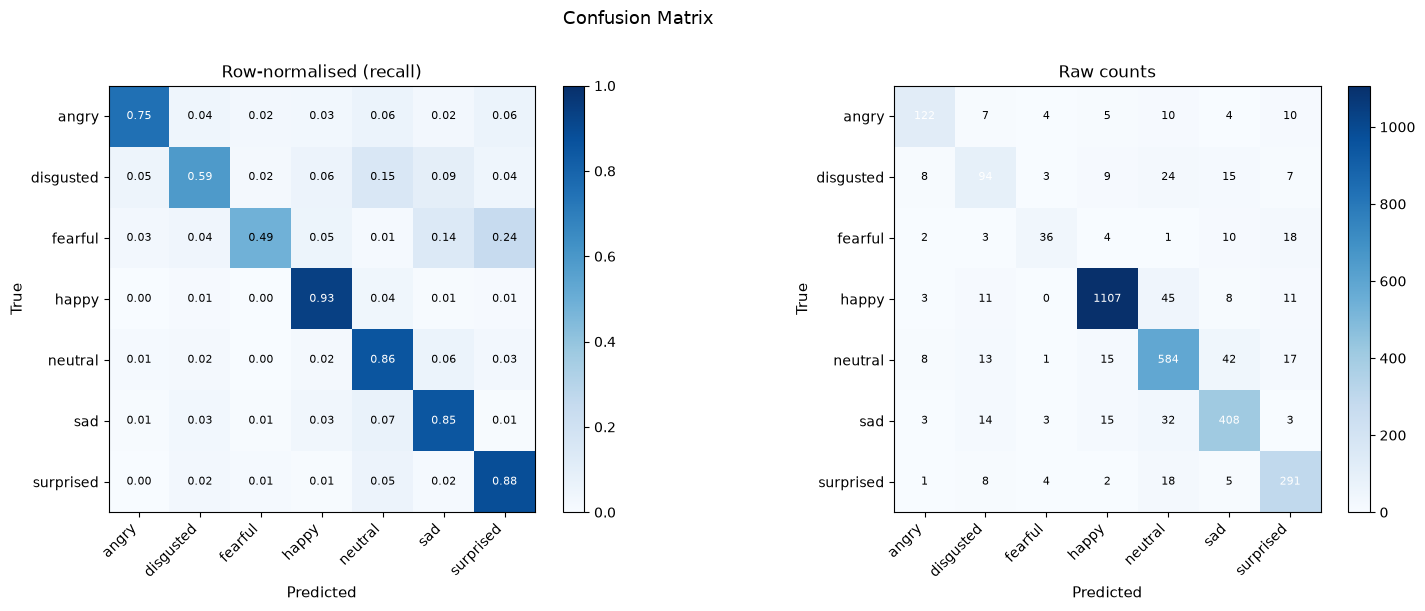

In [8]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, fmt in [
    (axes[0], cm_norm, "Row-normalised (recall)", "{:.2f}"),
    (axes[1], cm,      "Raw counts",              "{:d}"),
]:
    vmax = 1.0 if data is cm_norm else None
    im = ax.imshow(data, cmap="Blues", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(classes, fontsize=10)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(title, fontsize=12)
    for r in range(n_classes):
        for c in range(n_classes):
            color = "white" if cm_norm[r, c] > 0.5 else "black"
            val = data[r, c]
            ax.text(c, r, fmt.format(val),
                    ha="center", va="center", fontsize=8, color=color)

plt.suptitle("Confusion Matrix", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(images_path / "confusion_matrix_eval.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. ROC Curves & AUC (One-vs-Rest)

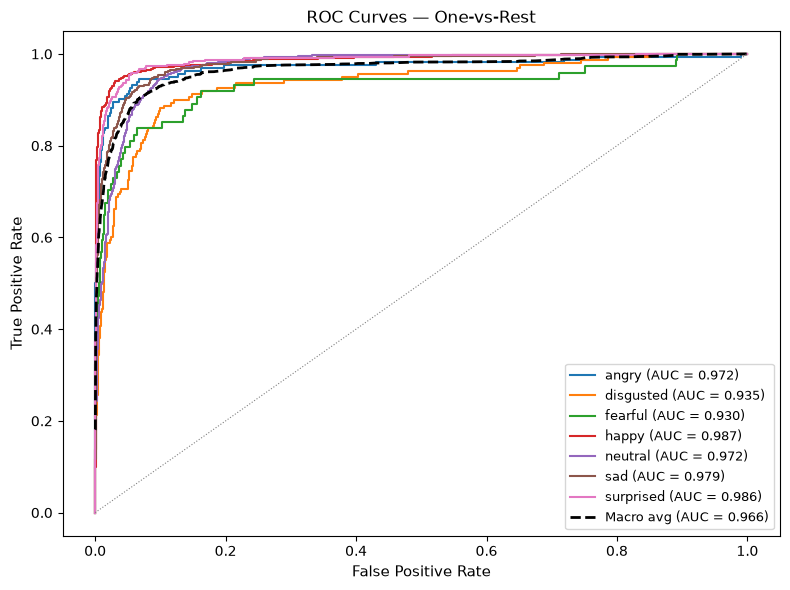

In [9]:
y_bin = label_binarize(all_labels, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(8, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=1.5, label=f"{cls} (AUC = {roc_auc:.3f})")

# Macro-average ROC
all_fpr = np.unique(np.concatenate([roc_curve(y_bin[:, i], all_probs[:, i])[0] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, "k--", linewidth=2, label=f"Macro avg (AUC = {macro_auc:.3f})")

ax.plot([0, 1], [0, 1], color="grey", linewidth=0.8, linestyle=":")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — One-vs-Rest", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(images_path / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Confidence Calibration

Fitted temperature: 0.940
ECE — raw: 0.0272 | temperature-scaled: 0.0230


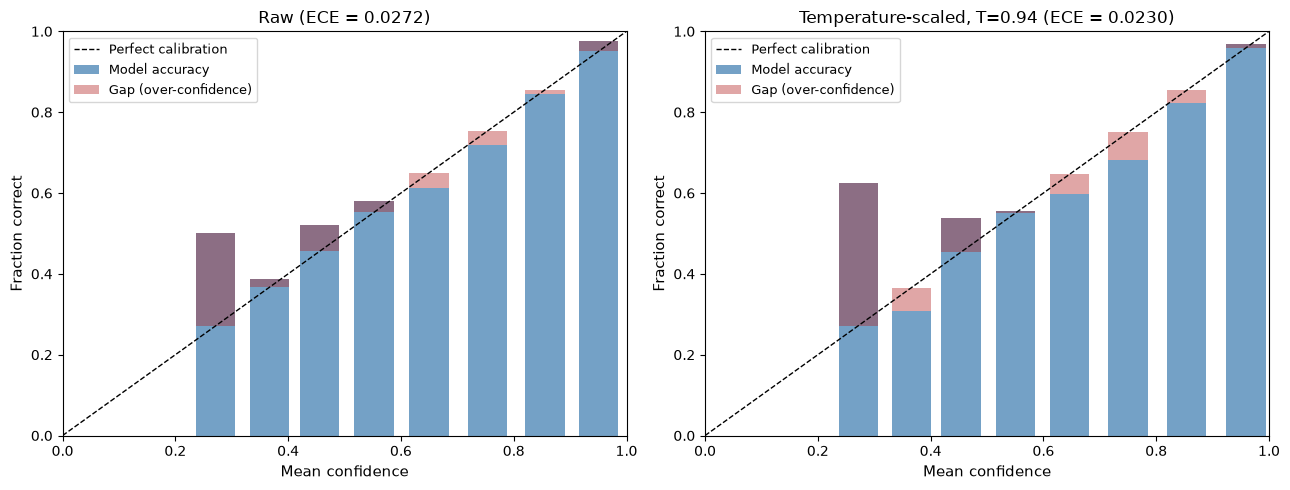

In [ ]:
def reliability_diagram(probs: np.ndarray, labels: np.ndarray, n_bins: int = 10):
    confidences = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    correct = (preds == labels).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_conf, bin_acc, bin_counts = [], [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences >= lo) & (confidences < hi)
        if mask.sum() == 0:
            continue
        bin_conf.append(confidences[mask].mean())
        bin_acc.append(correct[mask].mean())
        bin_counts.append(int(mask.sum()))

    ece = sum(
        cnt * abs(acc - conf)
        for acc, conf, cnt in zip(bin_acc, bin_conf, bin_counts)
    ) / len(labels)

    return np.array(bin_conf), np.array(bin_acc), np.array(bin_counts), ece


def fit_temperature(logits, labels, max_iter=200, lr=0.01):
    # Standard temperature scaling: a single scalar T that divides the
    # logits before softmax. Fit by minimizing NLL on the val set. Dividing every logit by
    # the same constant never changes the argmax, so accuracy/F1/ROC are unaffected — only
    # the confidence values (used for calibration) change.
    log_temp = torch.zeros(1, requires_grad=True)
    optimizer = torch.optim.LBFGS([log_temp], lr=lr, max_iter=max_iter)
    nll = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        loss = nll(logits / log_temp.exp(), labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return log_temp.exp().item()


temperature = fit_temperature(val_logits, val_labels_t)
test_probs_calibrated = F.softmax(test_logits / temperature, dim=1).numpy()

bin_conf_raw, bin_acc_raw, bin_counts_raw, ece_raw = reliability_diagram(all_probs, all_labels)
bin_conf_cal, bin_acc_cal, bin_counts_cal, ece_cal = reliability_diagram(test_probs_calibrated, all_labels)

print(f"Fitted temperature: {temperature:.3f}")
print(f"ECE — raw: {ece_raw:.4f} | temperature-scaled: {ece_cal:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, bin_conf, bin_acc, ece, title in [
    (axes[0], bin_conf_raw, bin_acc_raw, ece_raw, f"Raw (ECE = {ece_raw:.4f})"),
    (axes[1], bin_conf_cal, bin_acc_cal, ece_cal, f"Temperature-scaled, T={temperature:.2f} (ECE = {ece_cal:.4f})"),
]:
    width = 0.07
    ax.bar(bin_conf, bin_acc, width=width, alpha=0.75, label="Model accuracy", color="steelblue")
    ax.bar(bin_conf, bin_conf - bin_acc, width=width, bottom=bin_acc,
           alpha=0.4, color="firebrick", label="Gap (over-confidence)")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Mean confidence", fontsize=11)
    ax.set_ylabel("Fraction correct", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(images_path / "reliability_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Confidence Distribution — Correct vs. Incorrect

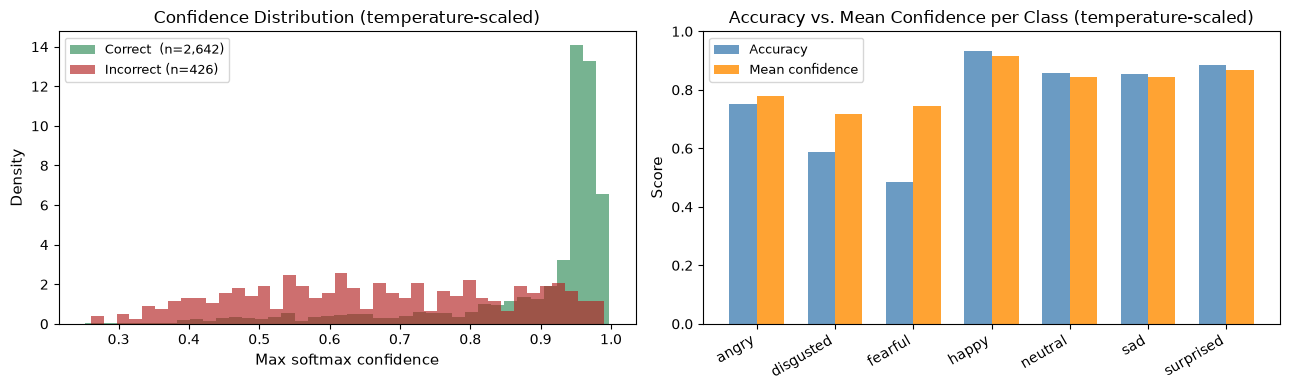

Mean confidence — correct: 0.8933 | incorrect: 0.6634


In [11]:
correct_mask = all_preds == all_labels
conf_all = test_probs_calibrated.max(axis=1)
conf_correct = conf_all[correct_mask]
conf_wrong = conf_all[~correct_mask]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(conf_correct, bins=40, alpha=0.65, density=True,
        label=f"Correct  (n={correct_mask.sum():,})", color="seagreen")
ax.hist(conf_wrong,   bins=40, alpha=0.65, density=True,
        label=f"Incorrect (n={(~correct_mask).sum():,})", color="firebrick")
ax.set_xlabel("Max softmax confidence", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Confidence Distribution (temperature-scaled)", fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
per_class_conf = [
    conf_all[all_labels == i].mean() for i in range(n_classes)
]
per_class_acc = [
    (all_preds[all_labels == i] == i).mean() for i in range(n_classes)
]
x = np.arange(n_classes)
w = 0.35
ax.bar(x - w / 2, per_class_acc,  width=w, label="Accuracy",        alpha=0.8, color="steelblue")
ax.bar(x + w / 2, per_class_conf, width=w, label="Mean confidence",  alpha=0.8, color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha="right", fontsize=10)
ax.set_ylim(0, 1)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Accuracy vs. Mean Confidence per Class (temperature-scaled)", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(images_path / "confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean confidence — correct: {conf_correct.mean():.4f} | incorrect: {conf_wrong.mean():.4f}")

## 8. Top-k Accuracy

/home/sera/Projects/image_emotion_detection/venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:2221: UndefinedMetricWarning: 'k' (7) greater than or equal to 'n_classes' (7) will result in a perfect score and is therefore meaningless.
  warnings.warn(


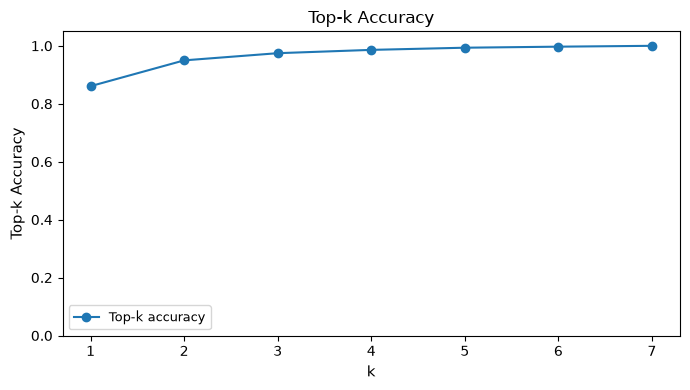

,Top-k accuracy
k,
1,0.8608
2,0.9498
3,0.9746
4,0.9860
5,0.9935
6,0.9971
7,1.0000


In [12]:
rows = []
for k in range(1, n_classes + 1):
    rows.append({"k": k, "Top-k accuracy": top_k_accuracy_score(all_labels, all_probs, k=k)})

df_topk = pd.DataFrame(rows).set_index("k")

fig, ax = plt.subplots(figsize=(7, 4))
df_topk.plot(ax=ax, marker="o")
ax.set_xlabel("k", fontsize=11)
ax.set_ylabel("Top-k Accuracy", fontsize=11)
ax.set_title("Top-k Accuracy", fontsize=12)
ax.set_xticks(range(1, n_classes + 1))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(images_path / "topk_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

df_topk.style.format("{:.4f}").set_caption("Top-k accuracy")